In [5]:
import os
import cv2
import tqdm
import glob
from collections import defaultdict

In [6]:
video_paths = sorted(glob.glob('./data/*/*/VIDEOS/*.mp4'))
print(f"Found {len(video_paths)} videos.")

Found 5708 videos.


In [9]:
num_frames = defaultdict(int)
num_samples = defaultdict(int)
for video_path in tqdm.tqdm(video_paths):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"Error opening video file {video_path}")
        continue

    dataset_name = video_path.split("/")[-4]
    num_frames[dataset_name] += int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    num_samples[dataset_name] += 1
    cap.release()

100%|██████████| 5708/5708 [00:54<00:00, 105.66it/s]


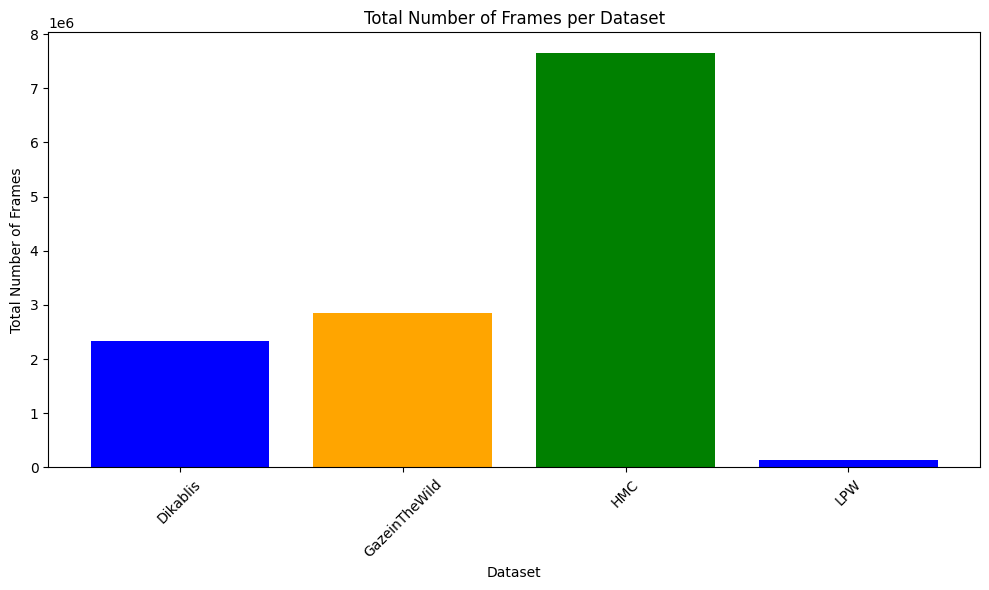

In [10]:
import matplotlib.pyplot as plt
datasets = list(num_frames.keys())
frame_counts = [num_frames[ds] for ds in datasets]

plt.figure(figsize=(10, 6))
plt.bar(datasets, frame_counts, color=['blue', 'orange', 'green'])
plt.xlabel('Dataset')
plt.ylabel('Total Number of Frames')
plt.title('Total Number of Frames per Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

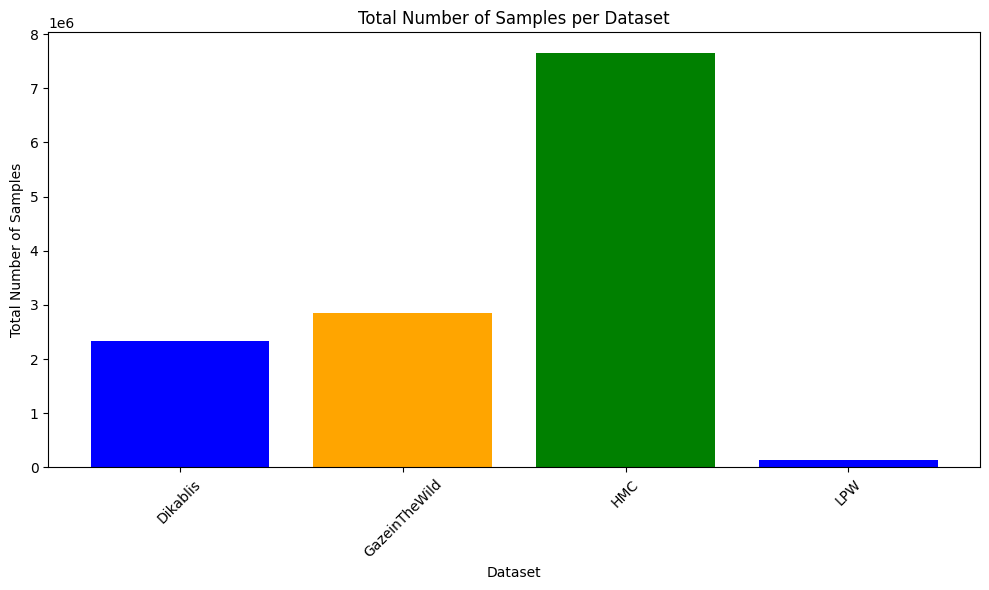

In [ ]:
datasets = list(num_samples.keys())
samples_count = [num_samples[ds] for ds in datasets]

plt.figure(figsize=(10, 6))
plt.bar(datasets, samples_count, color=['blue', 'orange', 'green'])
plt.xlabel('Dataset')
plt.ylabel('Total Number of Samples')
plt.title('Total Number of Samples per Dataset')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()